# Import Libraries

In [56]:
!pip install transformers datasets accelerate evaluate scikit-learn openpyxl sentencepiece


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import transformers
import torch
from collections import Counter

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss
from transformers import set_seed

SEED = 42
set_seed(SEED)

# Load Dataset

In [58]:
# ----- Define file paths ----------------------------
DATASET_PATH = "../dataset/emotion_dataset.csv"
SLANG_DICT_PATH = "../dataset/slang_dict.csv"

SAVE_PATH = "../models/indobert-emotion-classification-twitter"

In [59]:
df = pd.read_csv(DATASET_PATH)
df.head()

,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


### Data Validate

In [60]:
print("="*15, "Data Type Dataset:", "="*15)
print(df.shape)
print(df.info())

=============== Data Type Dataset: ===============
(4401, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4401 entries, 0 to 4400
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   4401 non-null   object
 1   tweet   4401 non-null   object
dtypes: object(2)
memory usage: 68.9+ KB
None


In [61]:
# ----- Normalize column name to match both dataset ------------
df.rename(columns={
    'tweet': 'text'
}, inplace=True)

In [62]:
# ----- Reorder columns ----------------------------
df = df[['text', 'label']]

In [63]:
# ----- Check label consistency -----------------
print(df['label'].unique())

# ----- lowercase df 'label' ----------------
df['label'] = df['label'].str.lower()

['anger' 'happy' 'sadness' 'love' 'fear']


# Exploratory Dataset Analytics (EDA)

In [64]:
# ----- Check missing value -------------
df.isnull().sum()

text     0
label    0
dtype: int64

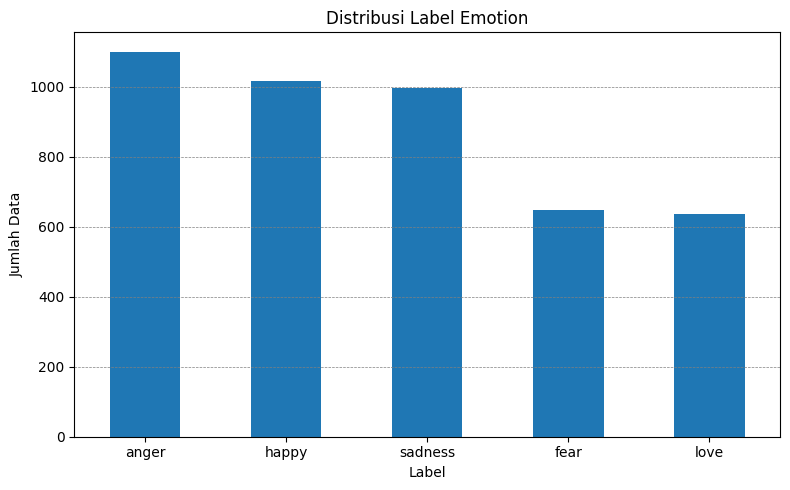

In [65]:
# -------- Check label distibution -------------
label_counts = df['label'].value_counts()

plt.figure(figsize=(8,5))
label_counts.plot(kind='bar')

plt.title("Distribusi Label Emotion")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle="--", color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

In [66]:
# ----- Long text statistic description -------------
df['text'].str.len().describe()

count    4401.000000
mean      182.352193
std        55.697054
min        12.000000
25%       147.000000
50%       178.000000
75%       226.000000
max       500.000000
Name: text, dtype: float64

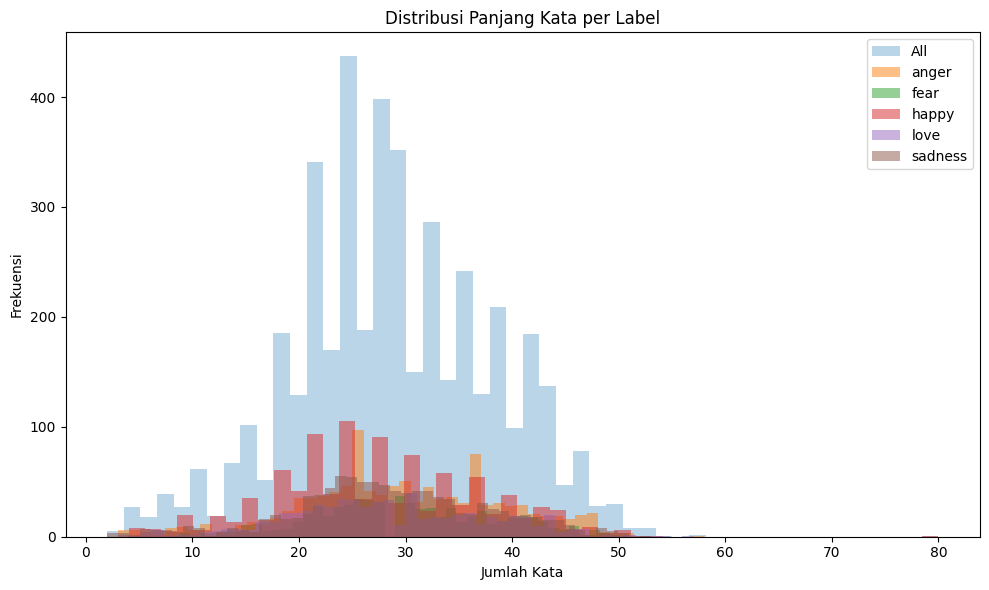

In [67]:
# ----- Plot histogram of word count per label -------------
word_count = df['text'].str.split().str.len()

plt.figure(figsize=(10, 6))

# ----- All data histogram -------------
plt.hist(
    word_count,
    bins=50,
    alpha=0.3,
    label='All'
)

# ------ Histogram per label -------------
for label, group in df.groupby('label'):
    plt.hist(
        group['text'].str.split().str.len(),
        bins=50,
        alpha=0.5,
        label=label
    )

plt.title('Distribusi Panjang Kata per Label')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.legend()

plt.tight_layout()
plt.show()

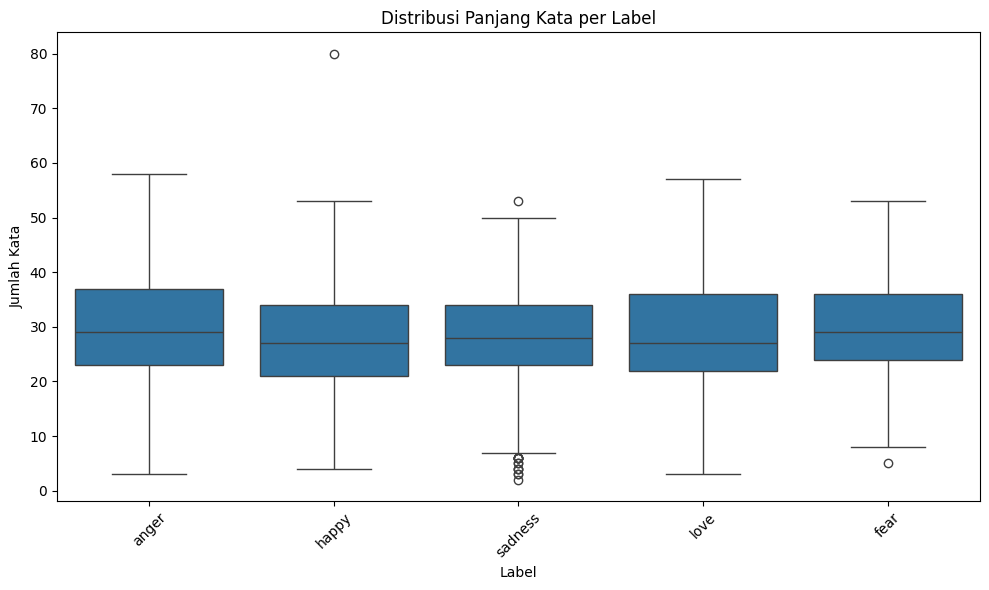

In [68]:
# ----- Boxplot of word count per label -------------
plt.figure(figsize=(10, 6))

sns.boxplot(x='label', y=df['text'].str.split().str.len(), data=df)

plt.title('Distribusi Panjang Kata per Label')
plt.xlabel('Label')
plt.ylabel('Jumlah Kata')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Data Preprocessing

In [69]:
# ----- Preprocessing function -------------
def preprocessing(text):
    text = str(text)

    text = text.lower() # lowercase
    text = re.sub(r'http\S+|www\S+', '', text) # hapus url, ex: https://instagram.com
    text = re.sub(r'@\w+', '', text) # hapus mention, ex: @joji
    text = re.sub(r'#', '', text) # hapus hashtag, ex: #joji -> joji
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # hapus karakter berulang, ex: gamauuuuuuuuuu
    # text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation))) # hapus tanda baca ganti spasi, ex: (,); (.); (!); (?)

    words = text.split() # tokenisasi

    # normalisasi slang word
    words = [
        slang_dict[word]
        if word in slang_dict else word
        for word in words
    ]

    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [70]:
# ----- Load slang dict and apply preprocessing -------------
slang_dict = pd.read_csv(SLANG_DICT_PATH)
slang_dict = dict(zip(slang_dict['before'], slang_dict['after']))
df['text'] = df['text'].apply(preprocessing)

In [71]:
# ----- Create word frequency dictionary -------------
word_counts = Counter()

for text in df['text']:
    words = str(text).split()
    word_counts.update(words)

dictionary = pd.DataFrame(
    word_counts.items(),
    columns=['word', 'frequency']
).sort_values(by='frequency', ascending=False)

dictionary.to_excel('word_dictionary.xlsx', index=False)

# Label Encoding

In [72]:
# ----- Mapping target labels -------------------
df['label'].value_counts()

label2id = {
    'anger': 0,
    'fear': 1,
    'happy': 2,
    'love': 3,
    'sadness': 4
}

id2label = {
    0: 'anger',
    1: 'fear',
    2: 'happy',
    3: 'love',
    4: 'sadness'
}
df['labels'] = df['label'].map(label2id)
df = df.rename(columns={'label': 'emotion_label'})

In [73]:
print("="*15, "Data After Preprocessing", "="*15)
print(df[['text','emotion_label','labels']].head())
print(df[['text', 'emotion_label', 'labels']].isna().sum())

=============== Data After Preprocessing ===============
                                                text emotion_label  labels
0  soal jalan jatibaru,polisi tidak bisa gertak g...         anger       0
1  sesama cewek lo (kayaknya), harusnya bisa lebi...         anger       0
2  ingin gudeg mbarek bu hj. amat foto dari googl...         happy       2
3  jalan jatibaru,bagian dari wilayah tn abang.pe...         anger       0
4  sharing pengalaman aja, kemarin jam 18.00 bata...         happy       2
text             0
emotion_label    0
labels           0
dtype: int64


# Train-Valid-Test Split Data

In [74]:
# ----- Split dataset into train, validation, and test set -------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['labels'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['labels'],
    random_state=42
)

In [75]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(3080, 3)
(660, 3)
(661, 3)


In [76]:
print(train_df['emotion_label'].value_counts(normalize=True))
print(val_df['emotion_label'].value_counts(normalize=True))
print(test_df['emotion_label'].value_counts(normalize=True))

emotion_label
anger      0.250000
happy      0.231169
sadness    0.226623
fear       0.147403
love       0.144805
Name: proportion, dtype: float64
emotion_label
anger      0.250000
happy      0.230303
sadness    0.225758
fear       0.148485
love       0.145455
Name: proportion, dtype: float64
emotion_label
anger      0.251135
happy      0.231467
sadness    0.226929
fear       0.146747
love       0.143722
Name: proportion, dtype: float64


# Load IndoBERT Tokenizer

In [77]:
# ----- Load Tokenizer -------------
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenization

In [78]:
# ----- Analyze token length distribution -------------
token_lengths = df['text'].apply(
    lambda x: len(tokenizer.encode(x))
)

print(token_lengths.describe())
print(token_lengths.quantile([0.5,0.9,0.95,0.999]))

count    4401.000000
mean       41.706885
std        12.732902
min         5.000000
25%        34.000000
50%        41.000000
75%        50.000000
max       124.000000
Name: text, dtype: float64
0.500    41.0
0.900    58.0
0.950    63.0
0.999    79.6
Name: text, dtype: float64


In [79]:
# ----- Tokenization function -------------
MAX_LENGTH = 80

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

data_collator = DataCollatorWithPadding(tokenizer)

# Class Weights Setting

In [80]:
# ----- Compute class weights for imbalanced dataset -------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["labels"]),
    y=train_df["labels"]
)

print(class_weights)

[0.8        1.35682819 0.86516854 1.38116592 0.88252149]


In [81]:
# ----- Convert class weights to tensor and move to GPU -------------
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).cuda()

print(class_weights)

tensor([0.8000, 1.3568, 0.8652, 1.3812, 0.8825], device='cuda:0')


# Configure Hugging Face Dataset

In [82]:
# ----- Create Hugging Face Dataset -------------
train_dataset = Dataset.from_pandas(
    train_df[['text', 'labels']]
)

val_dataset = Dataset.from_pandas(
    val_df[['text', 'labels']]
)

test_dataset = Dataset.from_pandas(
    test_df[['text', 'labels']]
)

In [83]:
# ----- Apply tokenization to the datasets -------------
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Map:   0%|          | 0/660 [00:00<?, ? examples/s]

Map:   0%|          | 0/661 [00:00<?, ? examples/s]

In [84]:
# ----- Set format to PyTorch tensors -------------
train_dataset.set_format(
    "torch",
    columns=["input_ids",
             "attention_mask",
             "labels"]
)

val_dataset.set_format(
    "torch",
    columns=["input_ids",
             "attention_mask",
             "labels"]
)

test_dataset.set_format(
    "torch",
    columns=["input_ids",
             "attention_mask",
             "labels"]
)

In [85]:
# ----- Load pre-trained model for sequence classification -------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Define Evaluation Metrics

In [86]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    labels, predictions, average='macro'
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,

        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

# Configure Training Arguments

In [87]:
# ----- Define TrainingArguments -------------
training_args = TrainingArguments(
    output_dir="../results",

    eval_strategy="epoch",
    save_strategy="epoch",

    # learning_rate=4e-5,
    # learning_rate=3e-5,
    # learning_rate=2e-5, 
    learning_rate=1e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=15,

    weight_decay=0.01,
    warmup_ratio=0.1,

    metric_for_best_model="macro_f1",
    load_best_model_at_end=True,
    
    fp16=True,

    logging_steps=50,

    report_to="none",

    seed=SEED
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [88]:
# ----- Create custom Trainer to include class weights in loss function -------------
class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fct = CrossEntropyLoss(
            weight=class_weights
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

# Model Training

In [89]:
# ----- Initialize the custom Trainer -------------
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    compute_metrics=compute_metrics
)

In [90]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,1.054569,0.904993,0.639394,0.642475,0.639207,0.640317,0.652426
2,0.723634,0.765847,0.713636,0.715737,0.712129,0.739677,0.704394
3,0.449689,0.819633,0.737879,0.736135,0.737382,0.739930,0.735448
4,0.221624,1.057956,0.750000,0.757351,0.751577,0.770288,0.750774
5,0.099189,1.295621,0.736364,0.743683,0.737951,0.757908,0.737126
6,0.078740,1.418697,0.753030,0.756718,0.752743,0.754684,0.759657


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2310, training_loss=0.4840841597034818, metrics={'train_runtime': 211.0676, 'train_samples_per_second': 218.887, 'train_steps_per_second': 27.361, 'total_flos': 567447163991424.0, 'train_loss': 0.4840841597034818, 'epoch': 6.0})

In [91]:
# ----- Save the fine-tuned model and tokenizer -------------
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/indobert-emotion-classification-twitter\\tokenizer_config.json',
 '../models/indobert-emotion-classification-twitter\\tokenizer.json')

# Evaluation

In [92]:
# ----- Evaluate on the test set -------------
test_result = trainer.evaluate(test_dataset)

print(test_result)
print(trainer.state.best_metric)
print(trainer.state.best_model_checkpoint)
print(trainer.args.load_best_model_at_end)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0.078740,0.990272,6,0.741301,0.754331,0.744141,0.760687,0.751710


{'eval_loss': 0.9902722239494324, 'eval_accuracy': 0.7413010590015129, 'eval_macro_f1': 0.7543308687895555, 'eval_weighted_f1': 0.7441405007204135, 'eval_macro_precision': 0.7606872310299992, 'eval_macro_recall': 0.7517103578208015}
0.7573514239441623
../results\checkpoint-1540
True


In [93]:
# ----- Generate classification report and confusion matrix -------------
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(label2id.keys())
    )
)

              precision    recall  f1-score   support

       anger       0.80      0.70      0.75       166
        fear       0.82      0.77      0.80        97
       happy       0.78      0.75      0.76       153
        love       0.82      0.84      0.83        95
     sadness       0.58      0.69      0.63       150

    accuracy                           0.74       661
   macro avg       0.76      0.75      0.75       661
weighted avg       0.75      0.74      0.74       661



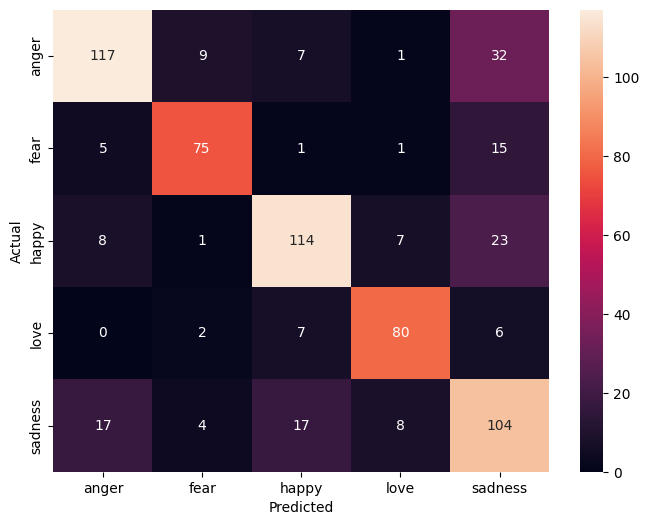

In [94]:
# ----- Plot confusion matrix -------------
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=list(label2id.keys()),
    yticklabels=list(label2id.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()